# setting

In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [2]:
!pip install -U ultralytics roboflow -q

In [3]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

/content/datasets


# download dataset from Roboflow

In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="LQEUDfrxIGMElgO3MiGp")
project = rf.workspace("auming-itkit-gmail-com").project("polyp_yolo_demo")
version = project.version(4)
dataset = version.download("yolo26")
print(f"\nDataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...

Dataset downloaded to: /content/datasets/polyp_yolo_demo-4


# select device

In [5]:
import torch

if torch.cuda.is_available():
    device = 0
    gpu = torch.cuda.get_device_properties(device)
    print(f"Using CUDA GPU: {gpu.name}")
    print(f"GPU memory: {gpu.total_memory / 1024**3:.1f} GB")
else:
    device = "cpu"
    print("WARNING: CUDA is unavailable")

Using CUDA GPU: Tesla T4
GPU memory: 14.6 GB


# Train a YOLO26 polyp-detection

In [6]:
from pathlib import Path
import cv2
from ultralytics import YOLO

# Training configuration
EPOCHS = 65
img_size = 640
data_config = Path(dataset.location) / "data.yaml"
batch_size = 4
experiment_name = "yolo26n_polyp"
learning_rate = 0.01

# checkpoint
project_dir = Path("/content/runs/detect")
run_dir = project_dir / experiment_name
last_checkpoint = run_dir / "weights" / "last.pt"

if last_checkpoint.exists():
  print(f"Resuming training from: {last_checkpoint}")
  model = YOLO(str(last_checkpoint))
  results = model.train(
    resume=True,
    device=device,
  )
else:
  # Fine-tune pretrained YOLO26 Nano weights.
  print("No checkpoint found. Starting new training.")
  model = YOLO("yolo26n.pt")
  results = model.train(
      data=str(data_config),
      epochs=EPOCHS,
      imgsz=img_size,
      batch=batch_size,
      device=device,
      project=str(project_dir),
      name=experiment_name,
      lr0=learning_rate,
      plots=True,
      save=True,
      save_period=10,
      exist_ok=True,
  )

RUN_DIR = Path(model.trainer.save_dir)
print(f"\nTraining outputs: {RUN_DIR}")
print(f"Latest checkpoint: {RUN_DIR / 'weights' / 'last.pt'}")
print(f"Best model: {RUN_DIR / 'weights' / 'best.pt'}")

No checkpoint found. Starting new training.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/polyp_yolo_demo-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=65, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=

# Evaluate the best model and display all essential results

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 804.2±88.5 MB/s, size: 30.6 KB)
val: Scanning /content/datasets/polyp_yolo_demo-4/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 44.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 9.1it/s 5.5s
                   all        200        215      0.893      0.828      0.891      0.723
Speed: 3.1ms preprocess, 11.8ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/yolo26n_polyp/best_evaluation

Overall validation results
Precision:    0.8930
Recall:       0.8279
F1 score:     0.8592
mAP@0.50:     0.8911
mAP@0.50:95:  0.7231

Per-class results
Class                 Precision     Recall
     mAP50     mAP50-95
polyp         

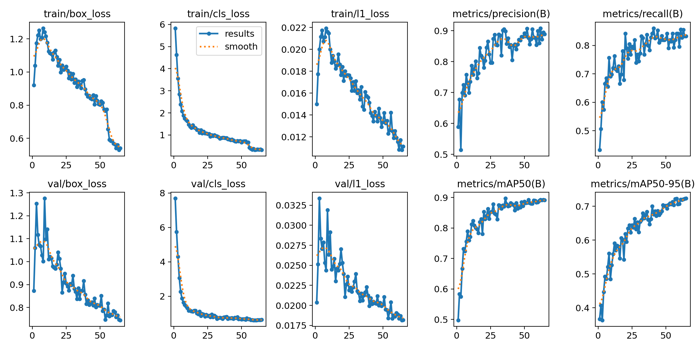


confusion_matrix.png


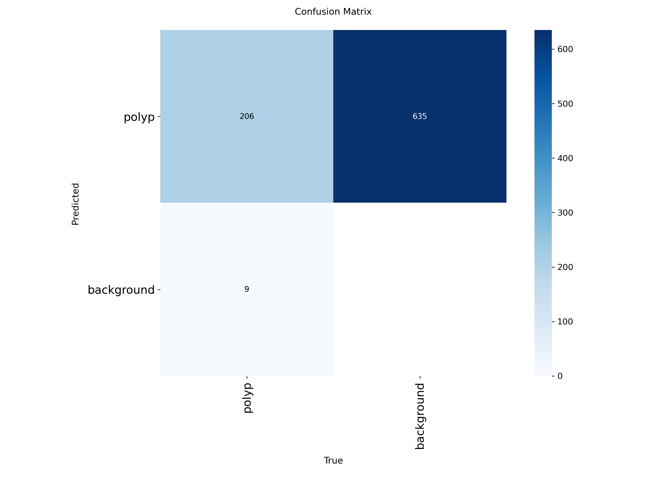


confusion_matrix_normalized.png


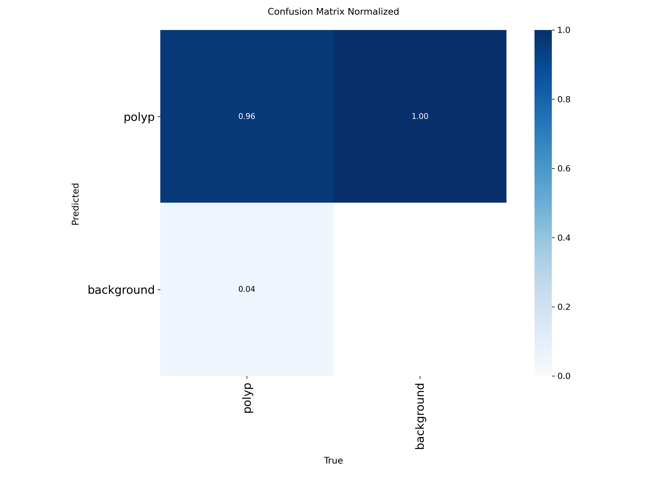


BoxPR_curve.png


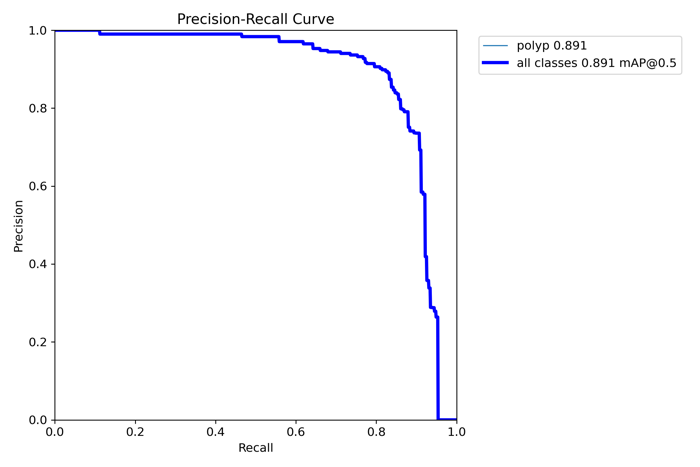


BoxF1_curve.png


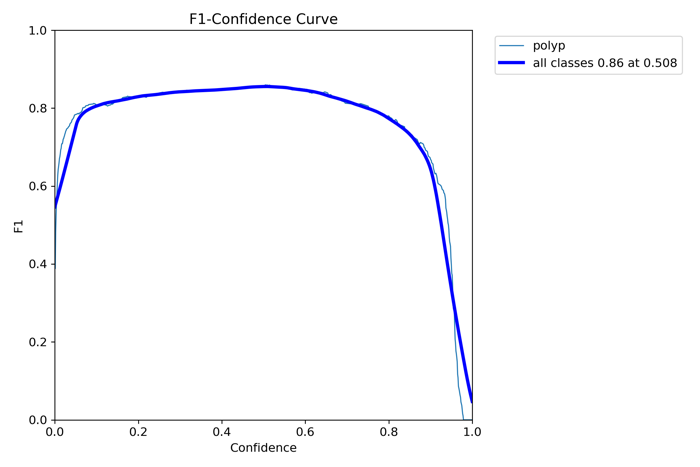


BoxP_curve.png


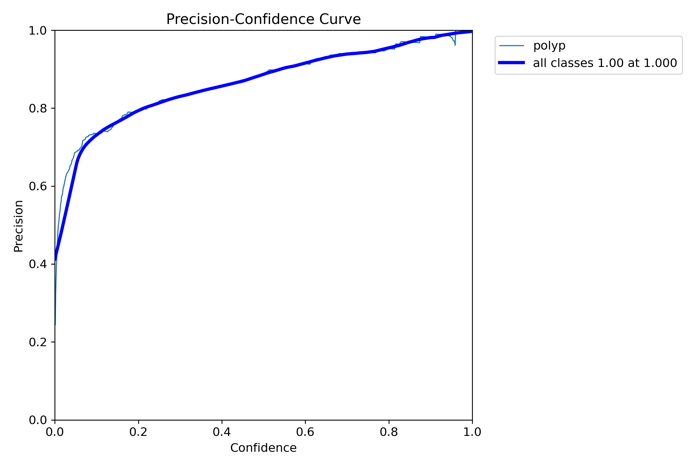


BoxR_curve.png


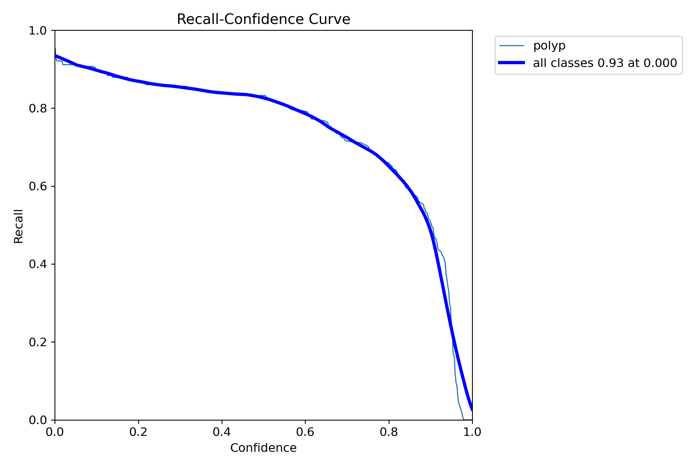

In [28]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
from pathlib import Path
import torch

best_model = YOLO(str(RUN_DIR / "weights" / "best.pt"))
eval_dir = RUN_DIR / "best_evaluation"

metrics = best_model.val(
    data=str(data_config),
    split="val",
    imgsz=img_size,
    batch=batch_size,
    device=0 if torch.cuda.is_available() else "cpu",
    conf=0.001,
    iou=0.7,
    plots=True,
    project=str(RUN_DIR),
    name="best_evaluation",
    exist_ok=True,
)

# Overall metrics
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
f1 = 2 * precision * recall / (precision + recall + 1e-12)

print("\nOverall validation results")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1 score:     {f1:.4f}")
print(f"mAP@0.50:     {float(metrics.box.map50):.4f}")
print(f"mAP@0.50:95:  {float(metrics.box.map):.4f}")

# Per-class metrics
print("\nPer-class results")
print(f"{'Class':20} {'Precision':>10} {'Recall':>10}\n{'mAP50':>10} {'mAP50-95':>12}")

for i, class_id in enumerate(metrics.box.ap_class_index):
    class_id = int(class_id)
    print(
        f"{best_model.names[class_id]:20} "
        f"{float(metrics.box.p[i]):10.4f} "
        f"{float(metrics.box.r[i]):10.4f} "
        f"{float(metrics.box.ap50[i]):10.4f} "
        f"{float(metrics.box.ap[i]):12.4f}"
    )

# Inference speed
print("\nSpeed per image")
for stage, milliseconds in metrics.speed.items():
    print(f"{stage.capitalize():15}: {milliseconds:.2f} ms")

# Display essential evaluation plots
plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]

print("\nEvaluation plots")
print(f"\nresults.png")
result_path = RUN_DIR / "results.png"
if result_path.exists():
    image = Image.open(result_path)
    image.thumbnail((700, 500))
    display(image)
for filename in plot_files:
    plot_path = eval_dir / filename

    if plot_path.exists():
        print(f"\n{filename}")
        plot = Image.open(plot_path)
        plot.thumbnail((700, 500))
        display(plot)
    else:
        print(f"Missing: {plot_path}")

## example predicted image from valid

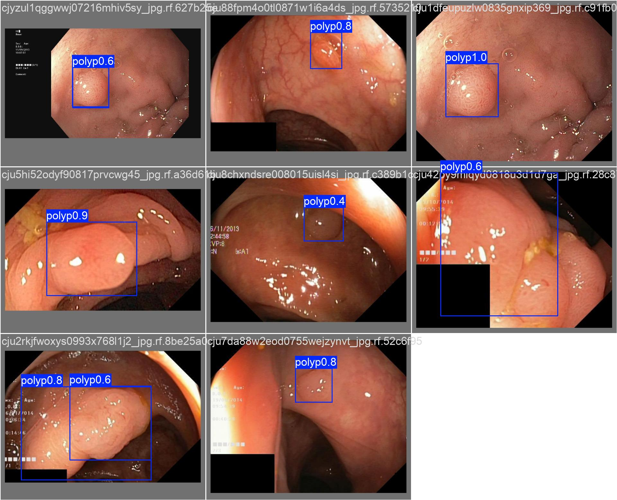

In [23]:
image_path = RUN_DIR / "val_batch0_pred.jpg"
image = Image.open(image_path)
image.thumbnail((700, 500))
display(image)

# download model

In [10]:
from google.colab import files

model_path = RUN_DIR / "weights" / "best.pt"
if not model_path.exists():
    raise FileNotFoundError(f"Trained model not found at {model_path}")
files.download(str(model_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# test setting

In [11]:
from pathlib import Path
from google.colab import files
from IPython.display import display
from PIL import Image
from ultralytics import YOLO
import torch

model_path = RUN_DIR / "weights" / "best.pt"
model = YOLO(str(model_path))

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: 0


# test

Saving images (2).jpg to images (2).jpg

image 1/1 /content/datasets/images (2).jpg: 384x640 1 polyp, 11.1ms
Speed: 2.2ms preprocess, 11.1ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/predictions/image_result
Result saved to: /content/predictions/image_result/images (2).jpg


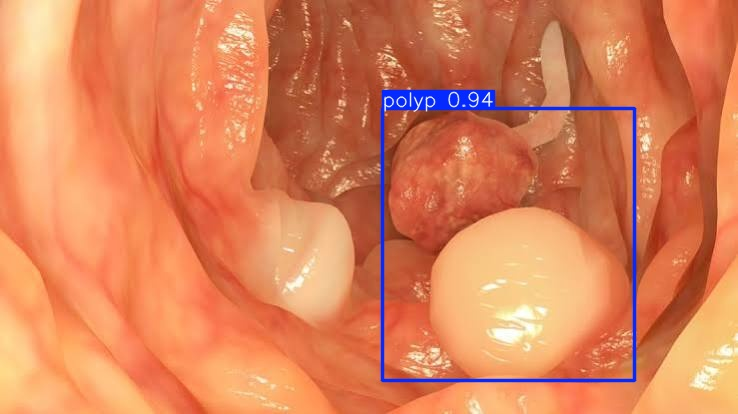

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError("No image was uploaded.")

input_path = Path(next(iter(uploaded)))

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if input_path.suffix.lower() not in image_extensions:
    raise ValueError("Please upload an image file.")

results = model.predict(
    source=str(input_path),
    conf=0.25,
    imgsz=640,
    device=device,
    save=True,
    project="/content/predictions",
    name="image_result",
    exist_ok=True,
)

output_dir = Path(results[0].save_dir)

output_files = [
    path for path in output_dir.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
]

matching_files = [
    path for path in output_files
    if path.stem == input_path.stem
]

if not matching_files:
    raise FileNotFoundError("Annotated image was not generated.")

output_path = matching_files[0]

print(f"Result saved to: {output_path}")

display(Image.open(output_path))
files.download(str(output_path))

In [15]:
uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError("No video was uploaded.")

input_path = Path(next(iter(uploaded)))

video_extensions = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

if input_path.suffix.lower() not in video_extensions:
    raise ValueError("Please upload a video file.")

results = model.predict(
    source=str(input_path),
    conf=0.25,
    imgsz=640,
    device=device,
    save=True,
    project="/content/predictions",
    name="video_result",
    exist_ok=True,
)

output_dir = Path(results[0].save_dir)

output_files = [
    path for path in output_dir.iterdir()
    if path.is_file() and path.suffix.lower() in video_extensions
]

if not output_files:
    raise FileNotFoundError("Processed video was not generated.")

matching_files = [
    path for path in output_files
    if path.stem == input_path.stem
]

output_path = matching_files[0] if matching_files else output_files[0]

print(f"Processed video saved to: {output_path}")

files.download(str(output_path))

Saving Screen Recording 2026-08-05 004328.mp4 to Screen Recording 2026-08-05 004328.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/140) /content/datasets/Screen Recording 2026-08-05 004328.mp4: 480x640 1 polyp, 99.6ms
video 1/1 (frame 2/140) /content/datasets/Screen Recording 2026-08-05 004328.mp4: 480x640 1 polyp, 14.1ms
video 1/1 (frame 3/140) /content/datasets/Screen Recording 2026-08-05 004328.mp4: 480x640 1 polyp, 16.8ms
video 1/1 (frame 4/140) /content/datasets/Screen Rec

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import base64
import cv2
import numpy as np

from google.colab import output
from IPython.display import Javascript, Image, display


def run_yolo_on_frame(image_data):
    try:
        encoded_image = image_data.split(",", 1)[1]

        # Decode browser image
        image_bytes = base64.b64decode(encoded_image)
        image_array = np.frombuffer(image_bytes, dtype=np.uint8)
        frame = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

        if frame is None:
            raise ValueError("Could not decode webcam frame.")

        # Run YOLO detection
        result = model.predict(
            source=frame,
            conf=0.25,
            imgsz=640,
            device=device,
            verbose=False,
        )[0]

        # Draw bounding boxes
        annotated_frame = result.plot()

        # Encode annotated frame as JPEG
        success, encoded_result = cv2.imencode(
            ".jpg",
            annotated_frame,
            [cv2.IMWRITE_JPEG_QUALITY, 80],
        )

        if not success:
            raise ValueError("Could not encode annotated frame.")

        # Return an actual JPEG response to JavaScript
        return Image(data=encoded_result.tobytes(), format="jpeg")

    except Exception as error:
        print(f"Webcam frame error: {error}")
        raise


output.register_callback(
    "polyp_detector.process_frame",
    run_yolo_on_frame,
)


webcam_javascript = Javascript("""
async function startPolypWebcam() {
    const previousContainer =
        document.getElementById("polyp-webcam-container");

    if (previousContainer) {
        previousContainer.remove();
    }

    const container = document.createElement("div");
    container.id = "polyp-webcam-container";

    const title = document.createElement("h3");
    title.textContent = "YOLO26 Polyp Detection";

    // Hidden source video used to capture webcam frames
    const video = document.createElement("video");
    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.playsInline = true;
    video.muted = true;
    video.style.display = "none";

    // Hidden canvas used to convert video into JPEG frames
    const canvas = document.createElement("canvas");
    canvas.width = 640;
    canvas.height = 480;
    canvas.style.display = "none";

    // Visible annotated YOLO result
    const resultImage = document.createElement("img");
    resultImage.width = 640;
    resultImage.height = 480;
    resultImage.style.display = "block";
    resultImage.style.backgroundColor = "black";
    resultImage.style.border = "1px solid #888";

    const stopButton = document.createElement("button");
    stopButton.textContent = "Stop Webcam";
    stopButton.style.display = "block";
    stopButton.style.marginTop = "10px";
    stopButton.style.padding = "8px 16px";

    const status = document.createElement("p");
    status.textContent = "Requesting webcam permission...";

    container.appendChild(title);
    container.appendChild(video);
    container.appendChild(canvas);
    container.appendChild(resultImage);
    container.appendChild(stopButton);
    container.appendChild(status);

    document.body.appendChild(container);

    let stream;

    try {
        stream = await navigator.mediaDevices.getUserMedia({
            video: {
                width: {ideal: 640},
                height: {ideal: 480}
            },
            audio: false
        });

        video.srcObject = stream;

        // Wait until the browser has webcam metadata
        await new Promise((resolve) => {
            video.onloadedmetadata = resolve;
        });

        await video.play();

    } catch (error) {
        console.error(error);
        status.textContent =
            "Camera access failed. Allow camera permission and run again.";
        return;
    }

    const context = canvas.getContext("2d");
    let running = true;

    stopButton.onclick = () => {
        running = false;

        if (stream) {
            stream.getTracks().forEach(track => track.stop());
        }

        status.textContent = "Webcam stopped.";
    };

    status.textContent =
        "Webcam started. Waiting for the first YOLO result...";

    while (running) {
        context.drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        const frameData =
            canvas.toDataURL("image/jpeg", 0.80);

        try {
            const response =
                await google.colab.kernel.invokeFunction(
                    "polyp_detector.process_frame",
                    [frameData],
                    {}
                );

            // Python returns IPython.display.Image
            const annotatedJpeg =
                response.data["image/jpeg"];

            if (annotatedJpeg) {
                resultImage.src =
                    "data:image/jpeg;base64," + annotatedJpeg;

                status.textContent =
                    "YOLO26 webcam detection running.";
            } else {
                status.textContent =
                    "Python returned no JPEG frame.";

                console.log(response.data);
            }

        } catch (error) {
            console.error(error);

            status.textContent =
                "Error processing webcam frame. Check the cell output.";

            break;
        }

        // Small delay before capturing the next frame
        await new Promise(resolve => setTimeout(resolve, 30));
    }
}

startPolypWebcam();
""")


display(webcam_javascript)

<IPython.core.display.Javascript object>